# Non-Instantaneous Earth Satellite Coverage Model

This Earth Satellite Coverage Model is built atop of the [Satellite Propagation Toolkit](https://github.com/rufusclark/Satellite-Propagation-Toolkit). To execute place and run this file from the root directory of the toolkit.

Comments, Limitations and Considerations
- The data presented in this analysis is for a single time point and the distribution of satellite throughout the Earth varies greatly as a function of time
- This model does not take into account the actual observation angle of optics, but rather uses the estimated observable angle, thus overestimating the area actually observed
- This model uses all satellites under the CelesTrak "Weather & Earth Resources Satellites" header

In [1]:
# install dependencies
%pip install -r requirements.txt
%pip install cartopy

# restart kernel (with new dependencies)
from IPython.display import display, Javascript
display(Javascript('IPython.notebook.kernel.restart()'))

%reset -f

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1 -> 25.3
[notice] To update, run: C:\Users\rufus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1 -> 25.3
[notice] To update, run: C:\Users\rufus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


<IPython.core.display.Javascript object>

In [2]:
# import all dependencies
from src import init_sats, SGP4Propagation, plot_orbital_overview, OrbitalPosition, wgs84, Satellite
from src.const import EARTH_RADIUS
from src.utility import ProgressBar, accept_any_datetime

from datetime import datetime, time, timedelta
import numpy as np

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from pyproj import Geod

# plt.style.use("default")
# plt.rcParams.update({
#     "mathtext.fontset": "cm",  # Computer Modern
#     "font.family": "serif"
# })

In [3]:
# Import satellite data

# Import all sats
sats = init_sats(update_sources=False)

# Number of sats
print(len(sats))

# Print out all satellite categories
sats.print_all_categories()
sats.print_all_constellations()

Using cached source groups
Loaded all 54 NORAD data sources                                                     
Loaded satcat.csv SATCAT data source
13923
{'communications satellites': 10982,
 'miscellaneous satellites': 68,
 'navigation satellites': 164,
 'scientific satellites': 56,
 'special-interest satellites': 2147,
 'weather & earth resources satellites': 506}
{'3CAT': 2,
 'AAC': 6,
 'ABS': 5,
 'AEHF': 6,
 'AEROCUBE': 11,
 'AETHER': 2,
 'AIST': 2,
 'AL': 3,
 'ALOS': 3,
 'ALSAT': 4,
 'AMAZONAS': 5,
 'AMC': 6,
 'AMOS': 3,
 'ANIK': 4,
 'ANSER': 3,
 'APRIZESAT': 10,
 'APSTAR': 6,
 'ARABSAT': 4,
 'ARIANE': 3,
 'ARIRANG': 3,
 'ARKTIKA': 2,
 'ARSAT': 2,
 'ARVAKER': 3,
 'ASBM': 2,
 'ASIASAT': 6,
 'ASNARO': 2,
 'ASTRA': 12,
 'ASTROCAST': 12,
 'ATHENA': 3,
 'ATLAS': 4,
 'AZERSPACE': 2,
 'BADR': 3,
 'BB': 2,
 'BEIDOU': 112,
 'BEIJING': 2,
 'BLACKJACK': 4,
 'BRITE': 4,
 'BRO': 13,
 'BSAT': 5,
 'BUFENG': 2,
 'CALSPHERE': 3,
 'CANX': 3,
 'CAPELLA': 6,
 'CARTOSAT': 7,
 'CBERS': 3,
 'CE': 2,
 

In [4]:
# Filter sats
# sats = sats.filter(lambda sat: sat.constellation == "SENTINEL")
# sats = sats.filter(lambda sat: sat.constellation == "SENTINEL").limit(1)
# sats = sats.filter(lambda sat: sat.name in ["SENTINEL-2A", "SENTINEL-2B"])
sats = sats.filter(lambda sat: sat.name in ["SENTINEL-1C", "SENTINEL-1D"])

# Number of sats
print(sats)

<Sats n=2>


In [5]:
# Ciara data
lookup_dict = {"FLOCK": {"FoV half angle degs": 1.5, "night mode": False, "instrument": "optical"}, "SKYSAT": {"FoV half angle degs": 7.5, "night mode": False, "instrument": "optical"}, "ICEYE": {"FoV half angle degs": 4.5, "night mode": True, "instrument": "radar"}, "CAPELLA": {"FoV half angle degs": 15, "night mode": True, "instrument": "radar"}, "SENTINEL": {"FoV half angle degs": 15, "night mode": False, "instrument": "optical"}, "WORLDVIEW": {"FoV half angle degs": 1.5, "night mode": False, "instrument": "optical"}, "OTHER": {"FoV half angle degs": 15, "night mode": False, "instrument": "optical"}}

def half_angle(sat: Satellite) -> float:
    """lookup half angle based on Ciara data on constellations field of view"""
    # Didn't realise these weren't the same as Ciara's data :(
    if sat.name.startswith("SENTINEL-1"):
        return 10.2
    if sat.name.startswith("SENTINEL-2"):
        return 10.3

    lookup_dict_keys = list(lookup_dict.keys())
    constellation = sat.constellation

    return lookup_dict[constellation if constellation in lookup_dict_keys else "OTHER"]["FoV half angle degs"]

def swath_ground_radius(theta_rad, h_km):
    # calculate angle and radius of horizon
    theta_horizon = np.asin(EARTH_RADIUS / (EARTH_RADIUS + h_km))
    r_horizon = EARTH_RADIUS * np.acos(EARTH_RADIUS / (EARTH_RADIUS + h_km))

    arg = (EARTH_RADIUS + h_km)/EARTH_RADIUS * np.sin(theta_rad)
    arg_clipped = np.clip(arg, -1, 1)

    # vectorised approach for future use
    return np.where(
        theta_rad <= theta_horizon,
        EARTH_RADIUS * (np.asin(arg_clipped) - theta_rad),
        r_horizon
    )

In [6]:
# Calculate the time to go across one swath width (diameter)

# ! Not verified

sat = sats.sats[0]

pos: OrbitalPosition = SGP4Propagation().propagate(sat, datetime.combine(datetime(2025, 11, 27).date(), time(12)))[0]

alt = pos.geo.alt
theta = np.radians(half_angle(sat))
swath_width = 2 * swath_ground_radius(theta, alt)
speed = pos.geo.total_velocity()
swath_width_pass_time = swath_width / speed

minimum_time_period_considered_a_pass = (swath_width * np.sqrt(1 - ((np.pi**2)/16)) ) / speed

print(f"{alt=:.3f}km\n{speed=:.3f}km/s\n{swath_width=:.3f}km\n{swath_width_pass_time=:.3f}s\n{minimum_time_period_considered_a_pass=:.3f}s")

alt=711.237km
speed=7.582km/s
swath_width=256.425km
swath_width_pass_time=33.819s
minimum_time_period_considered_a_pass=20.934s


In [7]:
# Get satellite positional data at given time (propagate and process)

# propagation time - you want this to be within 2 weeks +/- of current data epoch or the output will be unreliable
t0 = datetime.combine(datetime(2025, 11, 27).date(), time(12)) # today at noon
t1 = t0 + timedelta(days=30)
dt = timedelta(seconds=1)
# dt = timedelta(seconds=int(swath_width_pass_time))
steps = int((t1 - t0) / dt) + 1
num_sats = len(sats)
chunk_size = 10000

print(f"steps per sat = {steps}, total steps (number of SGP4 propagations) = {steps * num_sats}")

bar = ProgressBar(len(sats) * steps)

# preallocate np.arrays
latitudes = np.zeros((num_sats, steps), dtype=np.float64)
longitudes = np.zeros((num_sats, steps), dtype=np.float64)
ground_radius = np.zeros((num_sats, steps), dtype=np.float64)

times_dt = [t0 + dt * i for i in range(steps)]
times_posix = [t.timestamp() for t in times_dt]
times = np.array([times_posix[:] for _ in range(len(sats))])
times_skyfield = accept_any_datetime(times_dt)
times_skyfield_chunks = [times_skyfield[i:i+chunk_size] for i in range(0, len(times_skyfield), chunk_size)]

# for each sat
for j, sat in enumerate(sats.sats):

    # TODO: Utilise this massively in the manager or elsewhere

    FoV_rad = np.radians(half_angle(sat))

    # chunk for times
    for i, start in enumerate(range(0, steps, chunk_size)):
        bar.update(j * steps + start)

        end = min(start + chunk_size, steps)

        sat_pos = sat._sat.at(times_skyfield_chunks[i])
        geo_pos = wgs84.geographic_position_of(sat_pos)

        latitudes[j, start:end] = geo_pos.latitude.degrees # type: ignore
        longitudes[j, start:end] = geo_pos.longitude.degrees # type: ignore
        ground_radius[j, start:end] = swath_ground_radius(FoV_rad, geo_pos.elevation.km)

bar.update(bar.tasks)

steps per sat = 2592001, total steps (number of SGP4 propagations) = 5184002
[####################] 100.00% (eta: 0:00:00)


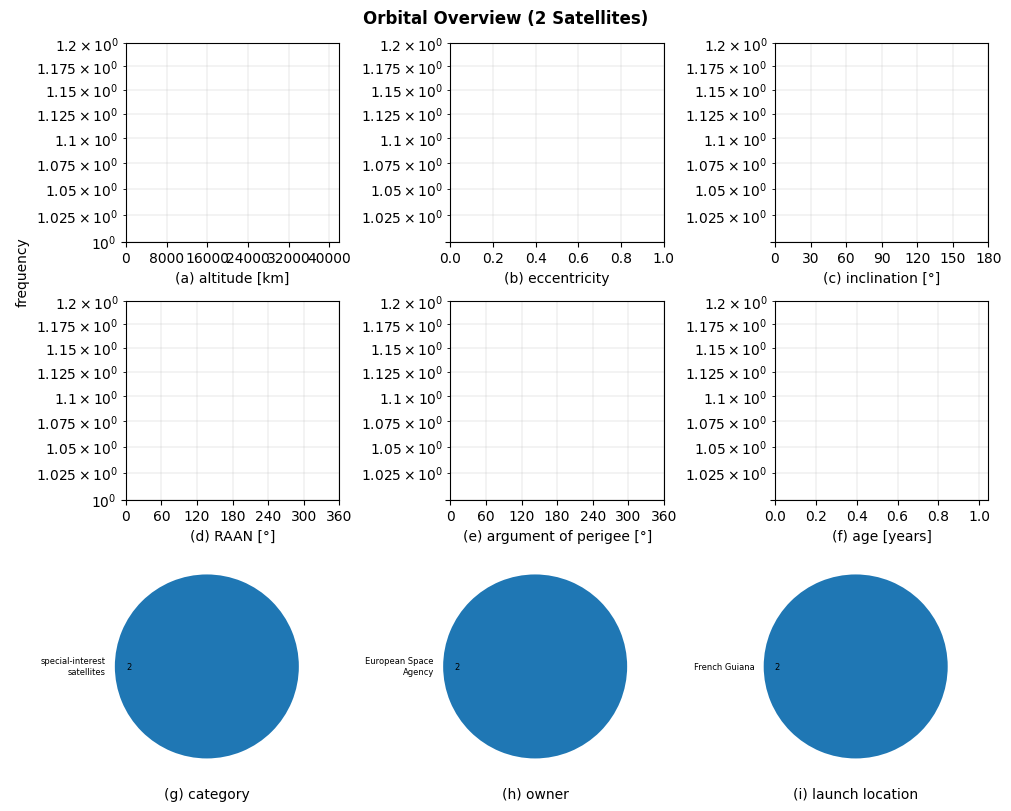

In [8]:
# Optionally, plot orbital overview

plot_orbital_overview(SGP4Propagation().propagate(sats, t0))

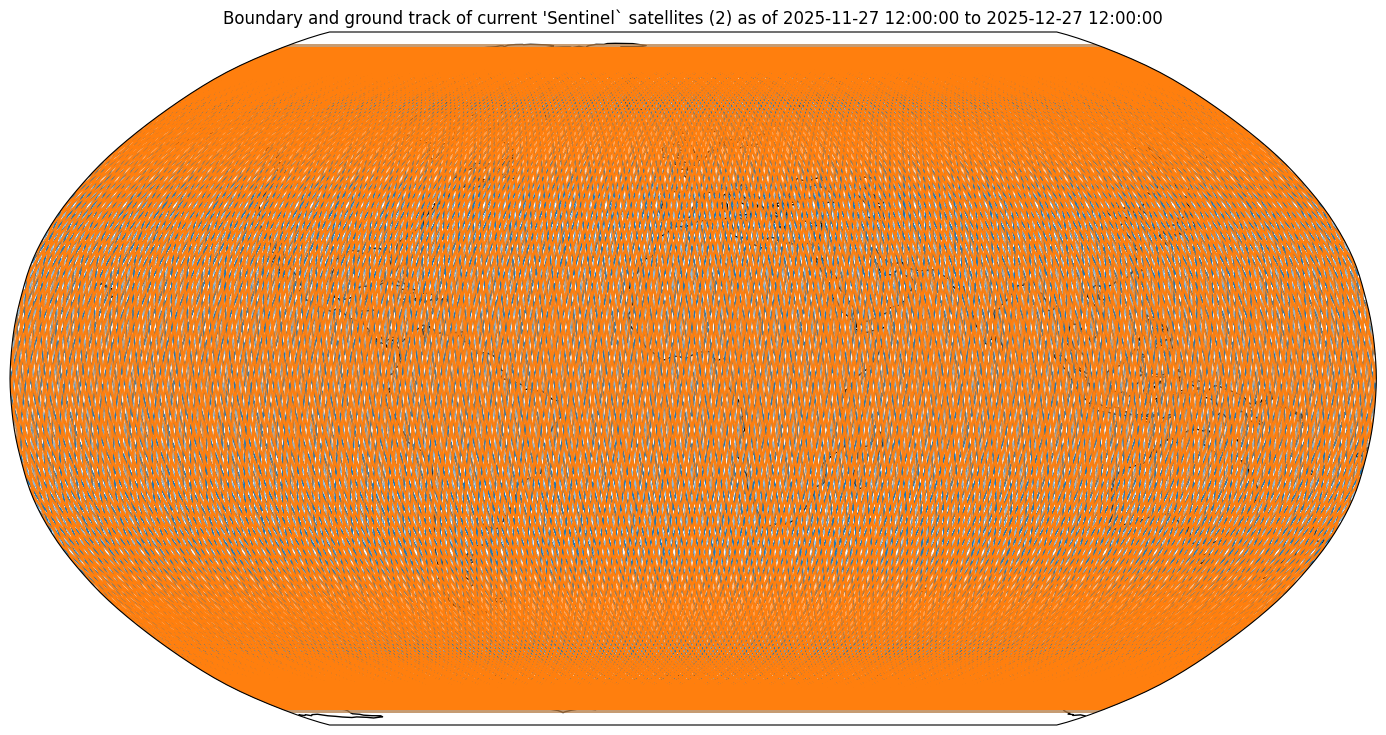

In [9]:
# Plot the boundary of coverage on a 2D map

# Earth model for geodesics
geod = Geod(ellps="WGS84")

# Plot
fig = plt.figure(figsize=(18, 9))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()

for sat_lats, sat_lons, r in zip(latitudes, longitudes, ground_radius):
    line, = ax.plot(sat_lons, sat_lats, transform=ccrs.Geodetic(), linewidth=0.8)
    colour = line.get_color()

    # compute ground track bearings
    bearings = geod.inv(sat_lons[:-1], sat_lats[:-1],
                        sat_lons[1:], sat_lats[1:])[0]
    
    # pad to same length
    bearings = np.append(bearings, bearings[-1])
    
    # left and right swath bearings
    left_bearings  = bearings + 90
    right_bearings = bearings - 90

    # km to m
    dist = r * 1000.0
    left_lons, left_lats, _ = geod.fwd(sat_lons, sat_lats, left_bearings, dist)
    right_lons, right_lats, _ = geod.fwd(sat_lons, sat_lats, right_bearings, dist)

    # plot boundaries
    ax.plot(left_lons, left_lats,  transform=ccrs.Geodetic(),
            linewidth=0.5, color=colour, alpha=0.5)
    ax.plot(right_lons, right_lats, transform=ccrs.Geodetic(),
            linewidth=0.5, color=colour, alpha=0.5)

plt.title(f"Boundary and ground track of current 'Sentinel` satellites ({len(sats)}) as of {t0} to {t1}")

plt.show()

In [10]:
# define fibonacci grid - almost perfectly distributed points on a sphere
# https://extremelearning.com.au/how-to-evenly-distribute-points-on-a-sphere-more-effectively-than-the-canonical-fibonacci-lattice/

resolution_km = 50

# calculate the number of points needed
n = np.ceil((4 * np.pi * EARTH_RADIUS**2)/(resolution_km)**2)

# generate fibonacci sphere coordinates
i = np.arange(n)
golden_ratio = (1 + 5**0.5)/2
theta = 2 * np.pi * i / golden_ratio
phi = np.arccos(1 - 2*(i)/n)

# convert to spherical coordinates
x, y, z = np.cos(theta) * np.sin(phi), np.sin(theta) * np.sin(phi), np.cos(phi)

# convert to lat/lon (degrees)
grid_lats = np.degrees(np.arcsin(y))
grid_lons = np.degrees(np.arctan2(z, x))

# Spot check instead
# grid_lats = np.array([55, 40, 11, 0])
# grid_lons = np.array([-3.5, -3.5, -4.3, 0])

# rectangular lat, lon grid
# lats = np.arange(-90, 91, 0.5)
# lons = np.arange(-180, 181, 0.5)
# lat_grid, lon_grid = np.meshgrid(lats, lons)
# grid_lats = lat_grid.ravel()
# grid_lons = lon_grid.ravel()

n = len(grid_lats)
print(f"Total grid points: {n:.0f}")

Total grid points: 204026


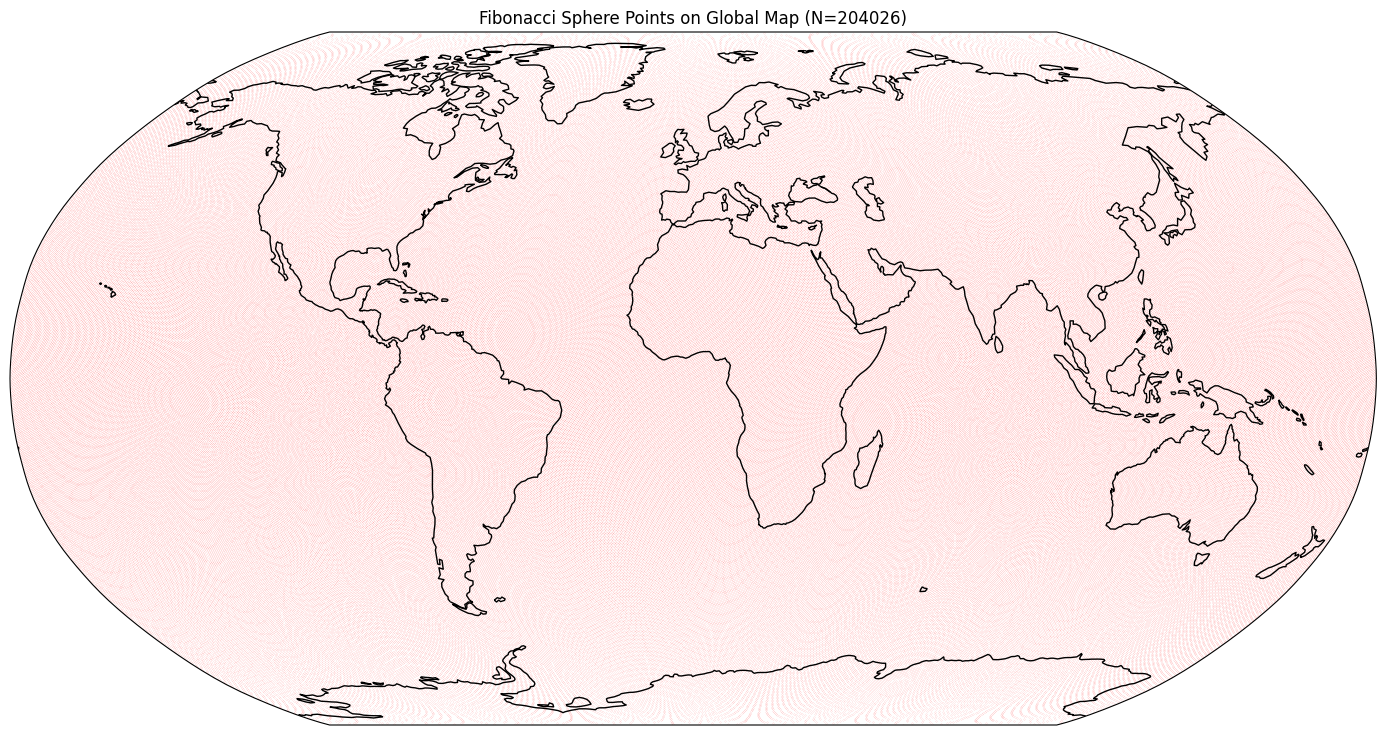

In [11]:
# plot fibonacci grid

# Plot
fig = plt.figure(figsize=(18, 9))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()

# Plot the points
s = 0.005 if n > 100 else 50
ax.scatter(grid_lons, grid_lats, s=s, color='red',alpha=0.7,transform=ccrs.Geodetic())

plt.title(f"Fibonacci Sphere Points on Global Map (N={len(grid_lats)})")
plt.show()

In [12]:
# coverage calculations

def great_circle_distance(lat1, lon1, lat2, lon2):
    """computes the great-circle distance in kilometres.

    uses the spherical law of cosines (accurate when distance is > 1m) otherwise you haversine formula

    typical error vs WGS-64 Ellipsoid is 0.1%-0.5%
    """

    dlon = lon2 - lon1

    return EARTH_RADIUS * np.acos(
        np.sin(lat1) * np.sin(lat2) + np.cos(lat1) * np.cos(lat2) * np.cos(dlon)
    )

coverage = np.zeros(grid_lons.shape, dtype=np.int16)
last_count_time = np.full(grid_lons.shape, -np.inf)

# precompute values for great circle calculations
grid_lats_rad = np.radians(grid_lats)
grid_lons_rad = np.radians(grid_lons)

outer_loops = latitudes.shape[0] # type: ignore
inner_loops = latitudes.shape[1] # type: ignore
bar = ProgressBar(outer_loops * inner_loops)

for i, (sat_lats, sat_lons, sat_rs, times1) in enumerate(zip(latitudes, longitudes, ground_radius, times)):

    # ! only consider descending passes
    if sats.sats[i].name.startswith("SENTINEL-2"):
        descending_mask = np.diff(sat_lats) < 0
        sat_lats = sat_lats[:-1][descending_mask]
        sat_lons = sat_lons[:-1][descending_mask]
        sat_rs = sat_rs[:-1][descending_mask]
        times1 = times1[:-1][descending_mask]

    # for each sat
    for j, (sat_lat, sat_lon, sat_r, t) in enumerate(zip(sat_lats, sat_lons, sat_rs, times1)):
        
        if j % (steps // 4) == 0:
            bar.update(i * inner_loops + j)

        # performance optimisations

        # pre-convert
        sat_lat_rad = np.radians(sat_lat)
        sat_lon_rad = np.radians(sat_lon)

        # bounding box calculations
        central_angle = sat_r / EARTH_RADIUS

        # latitude mask
        mask = np.abs(grid_lats_rad - sat_lat_rad) <= central_angle

        # skip if no points in bounding box
        if not np.any(mask):
            continue

        # end of performance optimisations

        # Great circle distance
        dist = great_circle_distance(grid_lats_rad[mask], grid_lons_rad[mask], sat_lat_rad, sat_lon_rad)

        # check if grid point is within radius
        within_swath_mask = dist <= sat_r

        # remove duplicate points (overlapping sat points in the same grid point)
        # remove_duplicate_pass_mask = ((t - last_count_time[mask] >= 600)) # 10 mins
        threshold = dt.total_seconds() * 2
        remove_duplicate_pass_mask = ((t - last_count_time[mask] >= threshold))

        # all valid points
        eligible_mask = within_swath_mask & remove_duplicate_pass_mask

        coverage[mask] += eligible_mask.astype(np.int16)
        last_count_time[mask] = np.where(eligible_mask, t, last_count_time[mask])

print(f"\nmax coverage = {max(coverage)}")

[################### ] 100.00% (eta: 0:00:00)
max coverage = 1613


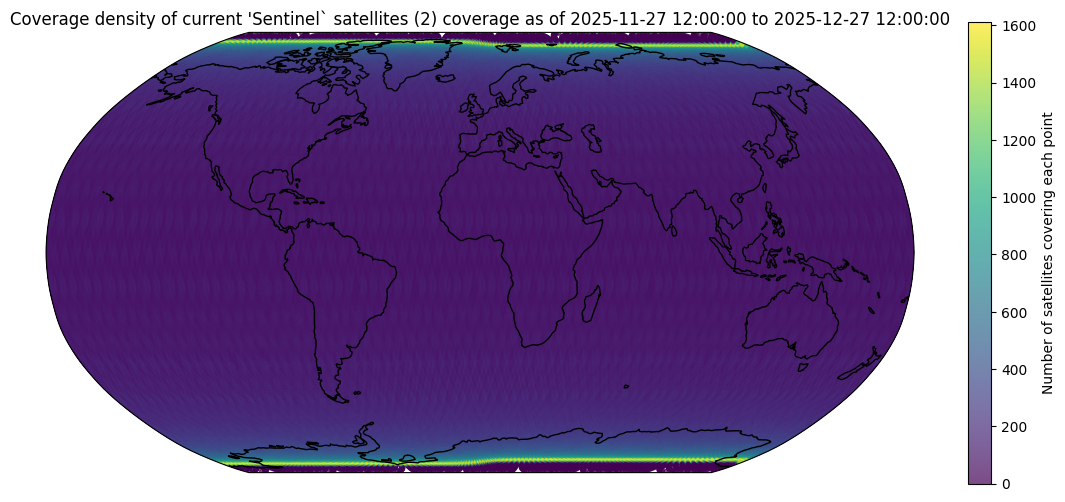

In [13]:
# Plot coverage

fig = plt.figure(figsize=(14, 6))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()
s = 10 if n > 100 else 50
sc = ax.scatter(grid_lons, grid_lats, c=coverage, s=s, cmap="viridis", alpha=0.7, transform=ccrs.Geodetic())
plt.colorbar(sc, orientation="vertical", label="Number of satellites covering each point")
plt.title(f"Coverage density of current 'Sentinel` satellites ({len(sats)}) coverage as of {t0} to {t1}")
plt.show()

In [14]:
# calculate mean revisit time
days = (t1 - t0).total_seconds()/(60*60*24)
mask = coverage > 0
mean_revisit_time = np.full_like(coverage, np.nan, dtype=float)
mean_revisit_time[mask] = days / coverage[mask]

# clean up artifacts near the poles
near_poles_mask = np.abs(grid_lats) > 80
near_poles_mode = np.unique(mean_revisit_time[near_poles_mask], return_counts=True)[0][np.argmax(np.unique(mean_revisit_time[near_poles_mask], 
return_counts=True)[1])]

print(f"{near_poles_mode=:.2f}")

mean_revisit_time[near_poles_mask] = near_poles_mode

# data processing
max_mean_revisit_time = max(mean_revisit_time)
mean_mean_revisit_time = np.nanmean(mean_revisit_time)
percentile_mean_revisit_time = np.nanpercentile(mean_revisit_time, 99.9)
print(f"max mean revisit time = {max_mean_revisit_time:.2f} days")
print(f"mean mean revisit time = {mean_mean_revisit_time:.2f} days")
print(f"99.9 percentile mean revisit time = {percentile_mean_revisit_time:.2f} days")

def nearest_mrt(query_lat, query_lon, lat, lon, mrt):
    dist = np.sqrt((lat - query_lat)**2 + (lon - query_lon)**2)
    idx = np.argmin(dist)
    return mrt[idx]

[print(f"{lat=:.1f} {lon=:.1f} mrt={nearest_mrt(lat, lon, grid_lats, grid_lons, mean_revisit_time)}") for lat, lon in zip([55, 40, 11, 0], [-3.5, -3.5, -4.3, 0])]

if n < 50:
    for i in range(len(mean_revisit_time)):
        print(f"lat={grid_lats[i]:.1f}°, lon={grid_lons[i]:.1f}°, mean revisit time={mean_revisit_time[i]:.2f} days")

near_poles_mode=nan
max mean revisit time = 0.48 days
mean mean revisit time = 0.25 days
99.9 percentile mean revisit time = 0.44 days
lat=55.0 lon=-3.5 mrt=0.16666666666666666
lat=40.0 lon=-3.5 mrt=0.22388059701492538
lat=11.0 lon=-4.3 mrt=0.22900763358778625
lat=0.0 lon=0.0 mrt=0.3191489361702128


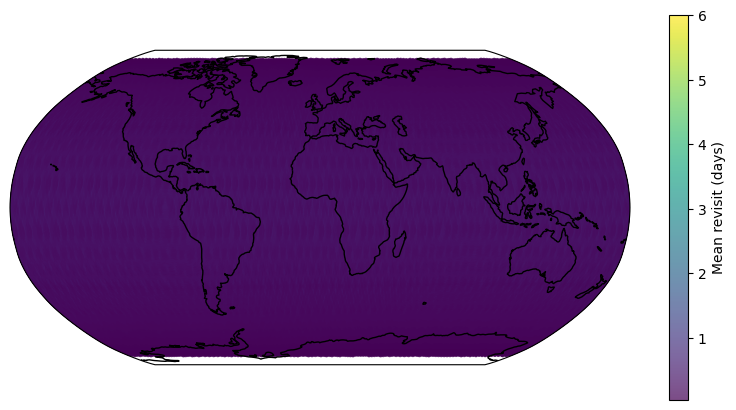

In [15]:
# Plot mean revisit time
cmap = plt.cm.viridis # type: ignore
cmap = cmap.copy()
cmap.set_over("yellow")

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global() # type: ignore
ax.coastlines() # type: ignore

s = 10 if n > 100 else 50
sc = ax.scatter(
    grid_lons,
    grid_lats,
    c=mean_revisit_time,
    cmap=cmap,
    s=5,
    alpha=0.7,
    vmax=6,
    transform=ccrs.PlateCarree(),
)
cb = plt.colorbar(sc, orientation="vertical", label="Mean revisit (days)")
cb.ax.tick_params(labelsize=10)
plt.savefig("./images/ciara paper/temp1.png")
plt.show()


# ax = plt.axes(projection=ccrs.Robinson())
# ax.set_global()
# ax.coastlines()
# s = 10 if n > 100 else 50
# sc = ax.scatter(grid_lons, grid_lats, c=mean_revisit_time, s=s, cmap="viridis", alpha=0.7, transform=ccrs.Geodetic(), vmin=0, vmax=percentile_mean_revisit_time)
# plt.colorbar(sc, orientation="vertical", label="Mean revisit [days]")
# # plt.title(f"Mean revisit time of current 'sentinel` satellites ({len(sats)}) coverage as of {t0} to {t1}")
# plt.show()

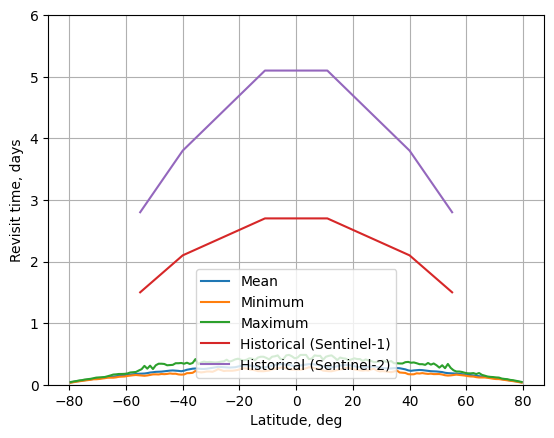

mean revisit at equator = 0.335


In [17]:
# plot mean revisit time vs latitude

# Define lat bins
lat_bins = np.arange(-80, 81, 1)
lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
num_bins = len(lat_bins) - 1

# preallocate arrays
mean_revisit_by_lat = np.full(num_bins, np.nan, dtype=np.float64)
min_revisit_by_lat = np.full(num_bins, np.nan, dtype=np.float64)
max_revisit_by_lat  = np.full(num_bins, np.nan, dtype=np.float64)

# remove outliers
for i in range(num_bins):
    mask = (grid_lats >= lat_bins[i]) & (grid_lats < lat_bins[i+1])

    if np.any(mask) and not np.all(np.isnan(mean_revisit_time[mask])):
        vals = mean_revisit_time[mask]

        # --- Remove 1% and 99% outliers ---
        vals_nonan = vals[~np.isnan(vals)]
        if len(vals_nonan) == 0:
            continue  # skip if no valid values

        low, high = np.percentile(vals_nonan, [0, 100])
        vals_filtered = vals_nonan[(vals_nonan >= low) & (vals_nonan <= high)]

        if len(vals_filtered) == 0:
            continue  # skip if filtering removed all values

        # Compute stats on filtered values
        mean_revisit_by_lat[i] = np.mean(vals_filtered)
        min_revisit_by_lat[i]  = np.min(vals_filtered)
        max_revisit_by_lat[i]  = np.max(vals_filtered)

# plot
plt.figure()
plt.plot(lat_centers, mean_revisit_by_lat, label="Mean")
plt.plot(lat_centers, min_revisit_by_lat, label="Minimum")
plt.plot(lat_centers, max_revisit_by_lat, label="Maximum")
plt.legend(loc="lower center")
plt.xlabel("Latitude, deg")
plt.ylabel("Revisit time, days")
plt.ylim(0, 6) # ! modified
plt.grid()
plt.savefig("./images/ciara paper/temp2.png")

plt.plot([-55, -40, -11, 0, 11, 40, 55], [1.5, 2.1, 2.7, 2.7, 2.7, 2.1, 1.5], label="Historical (Sentinel-1)")
plt.plot([-55, -40, -11, 0, 11, 40, 55], [2.8, 3.8, 5.1, 5.1, 5.1, 3.8, 2.8], label="Historical (Sentinel-2)")
plt.legend(loc="lower center")
plt.show()

print(f"mean revisit at equator = {max(mean_revisit_by_lat):.3f}")